# Credit Card Fraud Detection - Project Summary

**Context:** A bank wants to automatically detect fraudulent transactions in real time.  
**Dataset:** 284,807 transactions, 492 frauds (0.17%), Kaggle ULB  
**Approach:** Full ML pipeline — EDA → Preprocessing → Supervised → Unsupervised  
**Date:** May 2026

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import kagglehub, os

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Load Data

In [2]:
# Load data
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')

y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

X_train_resampled = pd.read_csv('../data/processed/X_train_resampled.csv')
y_train_resampled = pd.read_csv('../data/processed/y_train_resampled.csv').squeeze()

## 2. Modeling

In [3]:
# Retrain all models
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_resampled, y_train_resampled)

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_resampled, y_train_resampled)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_resampled, y_train_resampled)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight,
                    random_state=42, eval_metric='aucpr', n_jobs=-1)
xgb.fit(X_train, y_train)

print("All models retrained successfully.")

All models retrained successfully.


In [4]:
# Summary table
results = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Precision': 0.06, 'Recall': 0.92,
     'F1': 0.11, 'AUC-ROC': 0.9698, 'FN': 8, 'FP': 1458},
    {'Model': 'Decision Tree',       'Precision': 0.03, 'Recall': 0.90,
     'F1': 0.06, 'AUC-ROC': 0.9522, 'FN': 10, 'FP': 2896},
    {'Model': 'Random Forest',       'Precision': 0.82, 'Recall': 0.82,
     'F1': 0.82, 'AUC-ROC': 0.9688, 'FN': 18, 'FP': 17},
    {'Model': 'XGBoost',             'Precision': 0.88, 'Recall': 0.85,
     'F1': 0.86, 'AUC-ROC': 0.9652, 'FN': 15, 'FP': 11},
])

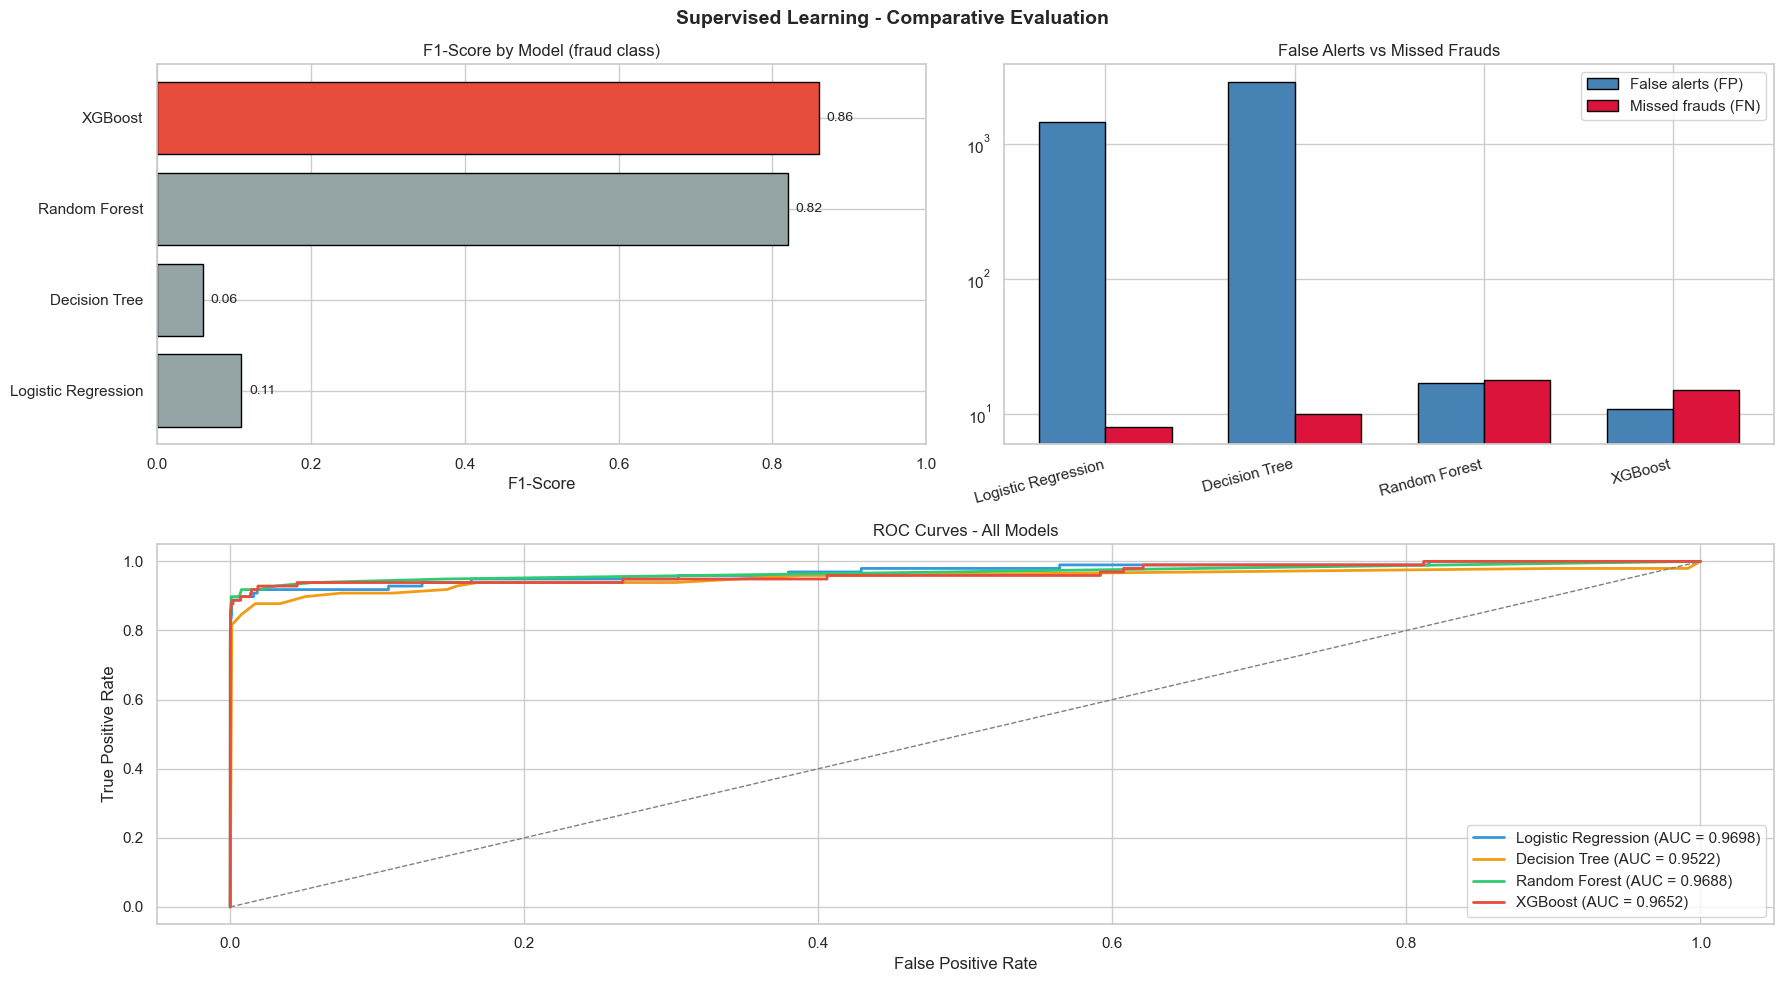

In [5]:
# Visualization
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Plot 1: F1 score comparison
ax1 = fig.add_subplot(gs[0, 0])
colors = ['#95a5a6', '#95a5a6', '#95a5a6', '#e74c3c']
bars = ax1.barh(results['Model'], results['F1'], color=colors, edgecolor='black')
ax1.set_title('F1-Score by Model (fraud class)')
ax1.set_xlabel('F1-Score')
ax1.set_xlim(0, 1)
for bar, val in zip(bars, results['F1']):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=10)

# Plot 2: False alerts vs missed frauds
ax2 = fig.add_subplot(gs[0, 1])
x = range(len(results))
width = 0.35
ax2.bar([i - width/2 for i in x], results['FP'], width,
        label='False alerts (FP)', color='steelblue', edgecolor='black')
ax2.bar([i + width/2 for i in x], results['FN'], width,
        label='Missed frauds (FN)', color='crimson', edgecolor='black')
ax2.set_title('False Alerts vs Missed Frauds')
ax2.set_xticks(list(x))
ax2.set_xticklabels(results['Model'], rotation=15, ha='right')
ax2.set_yscale('log')
ax2.legend()

# Plot 3: ROC curves
ax3 = fig.add_subplot(gs[1, :])
models = {
    'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'XGBoost': xgb,
}
colors_roc = ['#3498db', '#f39c12', '#2ecc71', '#e74c3c']
for (name, model), color in zip(models.items(), colors_roc):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax3.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {auc:.4f})')
ax3.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1)
ax3.set_title('ROC Curves - All Models')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.legend(loc='lower right')

plt.suptitle('Supervised Learning - Comparative Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Business Recommendation

### Problem
Detect fraudulent credit card transactions in real time, minimizing financial losses while keeping false alert rate acceptable for customers.

### Recommended Model - XGBoost

XGBoost achieves the best overall performance on this dataset:

| Metric | Value |
|---|---|
| F1-score (fraud) | **0.86** |
| Precision (fraud) | **0.88** |
| Recall (fraud) | **0.85** |
| AUC-ROC | 0.9652 |
| Missed frauds | 15 / 98 (15.3%) |
| False alerts | 11 / 56,864 (0.02%) |

### Key Findings

**1. Class imbalance is the central challenge**  

With only 0.17% fraud, accuracy is meaningless. SMOTE and `scale_pos_weight` were critical to force the model to learn fraud patterns.

**2. V14 is the dominant signal**  

Confirmed across EDA (strongest correlation), Decision Tree (first split), Random Forest and XGBoost (top feature importance). V14 alone carries most of the discriminative power.

**3. Unsupervised learning validates supervised findings**  

K-Means identified Cluster 3 with a 3.36% fraud rate (20x global average) without using any labels, confirming that fraud patterns are structurally distinct.

DBSCAN captured the most extreme anomalies but struggled with subtle frauds, as expected from an unsupervised approach.

### Limitations

- V1–V28 are PCA-anonymized, no business interpretation is possible. In production, explicit features (merchant category, geolocation, device) would improve explainability.
- The model was trained on 2 days of transactions: seasonal or behavioral drift may affect performance over time.
- DBSCAN was run on a subsample due to O(n²) memory complexity.

### Production Recommendation

Deploy XGBoost as a **real-time scoring API** (FastAPI):
- Score each transaction at authorization time
- Lower decision threshold to 0.3 to prioritize recall
- Monitor false positive rate weekly to avoid customer friction
- Retrain monthly on fresh labeled data to prevent model drift

## 4. Conclusion

This project covered the full ML lifecycle on a real-world imbalanced dataset:

| Phase | Key takeaway |
|---|---|
| EDA | Extreme imbalance (0.17%), accuracy is invalid |
| Preprocessing | SMOTE + stratified split essential for imbalanced data |
| Supervised | XGBoost best F1 (0.86), V14 dominant across all models |
| Unsupervised | K-Means confirms fraud clusters exist without labels |

**The combination of supervised and unsupervised approaches provides a robust, multi-angle view of fraud patterns, ready for production deployment.**